# Notebook 04 - Đánh giá và chọn model cuối

Thực hiện riêng Bước 4. Đầu vào: dataset.zip và training_artifacts.zip từ notebook 03. Đầu ra: ckd_final_artifacts.zip gồm model cuối, schema, metadata, bảng, hình và requirements.

## 0. Chạy trên Colab

Chọn Runtime → Run all, upload đồng thời hai file đầu vào. Notebook tái tạo đúng test split và chỉ đánh giá test tại bước này.

In [ ]:
from pathlib import Path
from google.colab import files
import io,json,shutil,sys,time,zipfile
from datetime import datetime,timezone
import joblib
import numpy as np
import pandas as pd
import sklearn

ROOT=Path('/content/ckd_colab'); DATA_PATH=ROOT/'dataset.zip'
TRAINING_ARCHIVE=ROOT/'training_artifacts.zip'; MODEL_DIR=ROOT/'models'
CANDIDATE_DIR=MODEL_DIR/'candidates'; FIGURE_DIR=ROOT/'docs'/'figures'
FINAL_EXPORT=ROOT/'final_export'
for directory in [ROOT,MODEL_DIR,CANDIDATE_DIR,FIGURE_DIR]:
    directory.mkdir(parents=True,exist_ok=True)

missing=[name for name in ['dataset.zip','training_artifacts.zip'] if not (ROOT/name).is_file()]
if missing:
    print('Upload đồng thời dataset.zip và training_artifacts.zip.')
    uploaded=files.upload()
    for name,content in uploaded.items(): (ROOT/Path(name).name).write_bytes(content)
missing=[name for name in ['dataset.zip','training_artifacts.zip'] if not (ROOT/name).is_file()]
if missing: raise FileNotFoundError('Thiếu file: '+', '.join(missing))
with zipfile.ZipFile(TRAINING_ARCHIVE) as archive: archive.extractall(MODEL_DIR)
print('Đã giải nén:',MODEL_DIR)

Đã giải nén: /content/ckd_colab/models


## 1. Cấu hình khớp bước 2–3

Feature, target, test_size và random_state không thay đổi. Assert phía sau kiểm tra schema và pipeline đã train.

In [ ]:
RANDOM_STATE=42; TEST_SIZE=0.20
TARGET='classification'; POSITIVE_LABEL='ckd'; NEGATIVE_LABEL='notckd'
NUMERIC_FEATURES=['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
CATEGORICAL_FEATURES=['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']
FEATURES=NUMERIC_FEATURES+CATEGORICAL_FEATURES
assert len(FEATURES)==24

## 2. Dùng lại đúng hàm đọc/làm sạch

Tái tạo deterministic split từ cùng dataset và random_state=42. Không fit lại candidate hoặc thay preprocessing sau khi xem test.

In [ ]:
def read_zip_dataset(path):
    with zipfile.ZipFile(path) as archive:
        names=[n for n in archive.namelist() if n.lower().endswith('.csv')]
        if len(names)!=1: raise ValueError(f'ZIP phải có đúng 1 CSV: {names}')
        return pd.read_csv(io.BytesIO(archive.read(names[0])))

def clean_dataframe(dataframe):
    df = dataframe.copy()

    # 1. Chuẩn hóa tên cột
    df.columns = [
        str(c).replace('\t', '').strip()
        for c in df.columns
    ]

    # 2. Kiểm tra cột bắt buộc
    missing = sorted(set(FEATURES + [TARGET]) - set(df.columns))
    if missing:
        raise ValueError(f'Thiếu cột: {missing}')

    # 3. Chuẩn hóa categorical + target
    for col in CATEGORICAL_FEATURES + [TARGET]:
        values = []

        for x in df[col]:
            if pd.isna(x):
                values.append(np.nan)
            else:
                x = str(x).replace('\t', '').strip().lower()
                values.append(np.nan if x in ['', '?'] else x)

        df[col] = pd.Series(values, index=df.index, dtype=object)

    # 4. Ép kiểu numeric
    for col in NUMERIC_FEATURES:
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        ).astype('float64')

    # 5. Kiểm tra target
    invalid = (
        set(df[TARGET].dropna().unique())
        - {POSITIVE_LABEL, NEGATIVE_LABEL}
    )

    if invalid:
        raise ValueError(f'Target không hợp lệ: {invalid}')

    # 6. Xóa dòng trùng
    return df.drop_duplicates().reset_index(drop=True)

from sklearn.model_selection import train_test_split
df=clean_dataframe(read_zip_dataset(DATA_PATH)); X=df[FEATURES].copy(); y=df[TARGET].copy()
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=y
)
print('Train tham chiếu:',X_train.shape,'| Test đánh giá cuối:',X_test.shape)

Train tham chiếu: (320, 24) | Test đánh giá cuối: (80, 24)


## 3. Kiểm tra schema, candidate và phiên bản

Model joblib có thể lỗi nếu scikit-learn/joblib khác phiên bản. Nếu không khớp, chạy lại notebook 03 và 04 trong cùng môi trường Colab.

In [ ]:
schema=json.loads((MODEL_DIR/'schema.json').read_text(encoding='utf-8'))
train_env=json.loads((MODEL_DIR/'training_environment.json').read_text(encoding='utf-8'))
current_env={'python':sys.version.split()[0],'pandas':pd.__version__,'numpy':np.__version__,
             'scikit-learn':sklearn.__version__,'joblib':joblib.__version__}
for library in ['scikit-learn','joblib']:
    if train_env[library]!=current_env[library]:
        raise RuntimeError(f'Phiên bản {library} không khớp: train={train_env[library]}, evaluate={current_env[library]}. Chạy lại notebook 03.')
assert schema['features']==FEATURES and schema['random_state']==RANDOM_STATE
candidate_paths=sorted(CANDIDATE_DIR.glob('*.joblib'))
if len(candidate_paths)!=5: raise FileNotFoundError(f'Cần 5 candidate, hiện có {len(candidate_paths)}.')
print('Schema, phiên bản và 5 candidate hợp lệ: OK')

Schema, phiên bản và 5 candidate hợp lệ: OK


## 4. Metric và ý nghĩa

F1 lớp ckd là metric chính. Báo cáo thêm Accuracy, Precision, Recall, ROC-AUC, PR-AUC và confusion matrix. Trong sàng lọc CKD, False Negative thường nguy hiểm hơn False Positive vì bỏ sót người bệnh.

## 5. Hàm đánh giá một candidate

Mỗi model predict cùng X_test. Đo timing 7 lần và lấy median để giảm nhiễu. Ma trận dùng thứ tự nhãn ckd, notckd nên ravel lần lượt là TP, FN, FP, TN.

In [ ]:
from sklearn.metrics import (accuracy_score,average_precision_score,confusion_matrix,
 f1_score,precision_score,recall_score,roc_auc_score,roc_curve)

def evaluate_candidate(path):
    pipeline=joblib.load(path)
    assert list(pipeline.named_steps['preprocessor'].feature_names_in_)==FEATURES
    timing=[]
    for _ in range(7):
        start=time.perf_counter(); predictions=pipeline.predict(X_test)
        timing.append(time.perf_counter()-start)
    index=list(pipeline.classes_).index(POSITIVE_LABEL)
    probabilities=pipeline.predict_proba(X_test)[:,index]
    binary=(y_test==POSITIVE_LABEL).astype(int)
    matrix=confusion_matrix(y_test,predictions,labels=[POSITIVE_LABEL,NEGATIVE_LABEL])
    tp,fn,fp,tn=matrix.ravel()
    fpr,tpr,_=roc_curve(binary,probabilities)
    row={'model':path.stem,
      'accuracy':float(accuracy_score(y_test,predictions)),
      'precision':float(precision_score(y_test,predictions,pos_label=POSITIVE_LABEL,zero_division=0)),
      'recall':float(recall_score(y_test,predictions,pos_label=POSITIVE_LABEL,zero_division=0)),
      'f1':float(f1_score(y_test,predictions,pos_label=POSITIVE_LABEL,zero_division=0)),
      'roc_auc':float(roc_auc_score(binary,probabilities)),
      'pr_auc':float(average_precision_score(binary,probabilities)),
      'true_positives':int(tp),'false_negatives':int(fn),
      'false_positives':int(fp),'true_negatives':int(tn),
      'predict_ms_per_sample':float(np.median(timing)/len(X_test)*1000),
      'model_size_bytes':path.stat().st_size}
    return row,matrix,(fpr,tpr)

## 6. Đánh giá đủ 5 model trên test đúng một lần

Không quay lại sửa grid sau khi xem kết quả test.

In [ ]:
rows=[]; confusion_matrices={}; roc_curves={}
for path in candidate_paths:
    print('Đang đánh giá:',path.stem)
    row,matrix,curve=evaluate_candidate(path)
    rows.append(row); confusion_matrices[path.stem]=matrix; roc_curves[path.stem]=curve
evaluation=pd.DataFrame(rows)
assert len(evaluation)==5
print('Đã đánh giá đủ 5 model.')

Đang đánh giá: dummy
Đang đánh giá: knn
Đang đánh giá: logistic_regression
Đang đánh giá: random_forest
Đang đánh giá: svc
Đã đánh giá đủ 5 model.


## 7. Ghép kết quả CV và bảng test

Xem đồng thời chất lượng test, gap train-test, CV stability, latency và size. Chỉ lấy cột train cần thiết để tránh trùng tên khi merge.

In [ ]:
training=pd.read_csv(MODEL_DIR/'training_results.csv')
columns=['model','cv_f1','cv_f1_std','cv_train_f1','train_f1','train_seconds']
evaluation=evaluation.merge(training[columns],on='model',how='left')
evaluation['train_test_f1_gap']=evaluation['train_f1']-evaluation['f1']
evaluation=evaluation.sort_values(['f1','recall'],ascending=False).reset_index(drop=True)
evaluation.to_csv(MODEL_DIR/'evaluation_results.csv',index=False)
display(evaluation[['model','accuracy','precision','recall','f1','roc_auc','pr_auc',
 'cv_f1','cv_f1_std','train_test_f1_gap','false_positives','false_negatives',
 'predict_ms_per_sample','model_size_bytes']])

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_f1,cv_f1_std,train_test_f1_gap,false_positives,false_negatives,predict_ms_per_sample,model_size_bytes
0,logistic_regression,1.0000,1.000000,1.00,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0,0,0.193444,2665
1,random_forest,0.9875,0.980392,1.00,0.990099,0.999333,0.999608,0.997531,0.004938,0.009901,1,0,0.822007,61050
2,svc,0.9875,1.000000,0.98,0.989899,1.000000,1.000000,0.997468,0.005063,0.010101,0,1,0.218506,5342
3,knn,0.9750,1.000000,0.96,0.979592,0.998667,0.999231,0.974292,0.008318,0.020408,0,2,0.401928,17625
4,dummy,0.6250,0.625000,1.00,0.769231,0.500000,0.625000,0.769231,0.000000,0.000000,30,0,0.161038,2206


## 8. Giải thích model tốt/xấu

So với Dummy; gap > 0.10 cảnh báo overfitting; train/test cùng thấp cảnh báo underfitting; xem FN/FP và CV std thay vì chỉ Accuracy.

In [ ]:
baseline=float(evaluation.loc[evaluation.model=='dummy','f1'].iloc[0])
for row in evaluation.itertuples():
    if row.train_test_f1_gap>0.10: fit_status='nguy cơ overfitting'
    elif row.train_f1<0.70 and row.f1<0.70: fit_status='nguy cơ underfitting'
    else: fit_status='gap train-test chấp nhận được'
    compare='tốt hơn Dummy' if row.f1>baseline else 'baseline hoặc không hơn Dummy'
    print(f'{row.model}: F1={row.f1:.3f}, Recall={row.recall:.3f}, AUC={row.roc_auc:.3f}, '
          f'FN={row.false_negatives}, FP={row.false_positives}; {compare}; {fit_status}; '
          f'CV std={row.cv_f1_std:.4f}.')

logistic_regression: F1=1.000, Recall=1.000, AUC=1.000, FN=0, FP=0; tốt hơn Dummy; gap train-test chấp nhận được; CV std=0.0000.
random_forest: F1=0.990, Recall=1.000, AUC=0.999, FN=0, FP=1; tốt hơn Dummy; gap train-test chấp nhận được; CV std=0.0049.
svc: F1=0.990, Recall=0.980, AUC=1.000, FN=1, FP=0; tốt hơn Dummy; gap train-test chấp nhận được; CV std=0.0051.
knn: F1=0.980, Recall=0.960, AUC=0.999, FN=2, FP=0; tốt hơn Dummy; gap train-test chấp nhận được; CV std=0.0083.
dummy: F1=0.769, Recall=1.000, AUC=0.500, FN=0, FP=30; baseline hoặc không hơn Dummy; gap train-test chấp nhận được; CV std=0.0000.


## 9. Biểu đồ so sánh metric

Hình này đưa vào báo cáo/slide; Dummy thể hiện mức baseline.

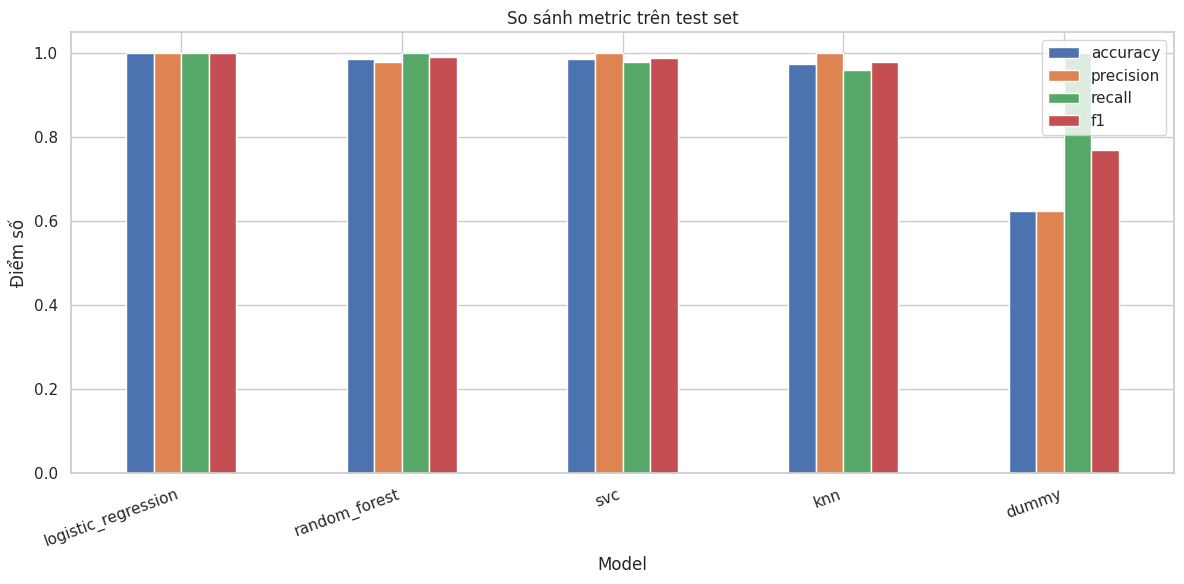

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
axis=evaluation.set_index('model')[['accuracy','precision','recall','f1']].plot(
    kind='bar',figsize=(12,6),ylim=(0,1.05))
axis.set(title='So sánh metric trên test set',xlabel='Model',ylabel='Điểm số')
plt.xticks(rotation=20,ha='right'); plt.tight_layout()
plt.savefig(FIGURE_DIR/'model_comparison.png',dpi=180,bbox_inches='tight'); plt.show()

## 10. ROC curve

Đường gần góc trên trái và AUC cao là tốt, nhưng phải đọc cùng Recall, Precision và confusion matrix.

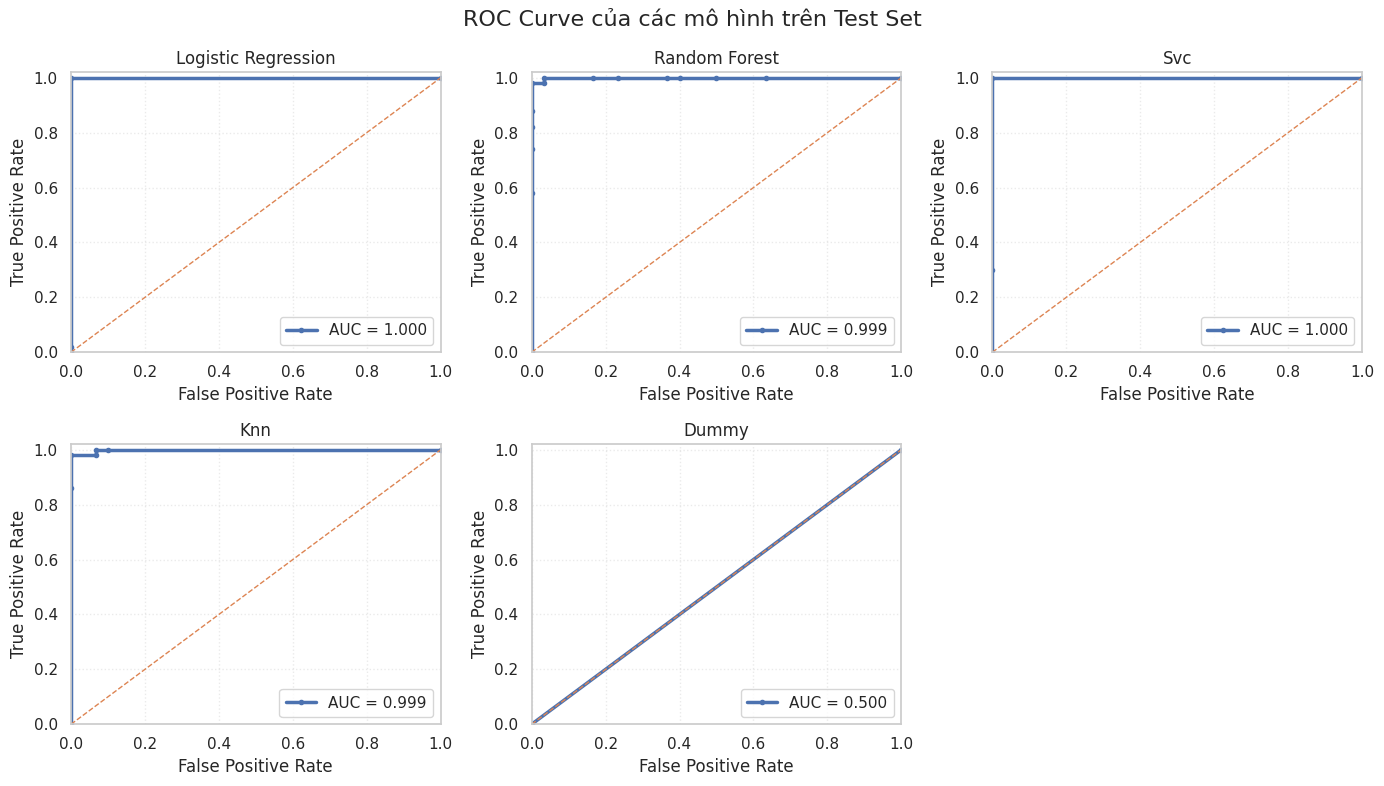

In [ ]:
import matplotlib.pyplot as plt

models = [row.model for row in evaluation.itertuples()]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, row in zip(axes, evaluation.itertuples()):
    fpr, tpr = roc_curves[row.model]

    ax.plot(
        fpr, tpr,
        linewidth=2.5,
        marker='o',
        markersize=3,
        markevery=max(1, len(fpr)//10),
        label=f"AUC = {row.roc_auc:.3f}"
    )

    ax.plot([0, 1], [0, 1], '--', linewidth=1)

    ax.set_title(row.model.replace('_', ' ').title())
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='lower right')

# Xóa ô thừa
for ax in axes[len(models):]:
    ax.axis('off')

fig.suptitle("ROC Curve của các mô hình trên Test Set", fontsize=16)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'roc_curve_separate.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

## 11. Ma trận nhầm lẫn

Với thứ tự ckd/notckd: trên trái TP, trên phải FN, dưới trái FP, dưới phải TN. FN là ca CKD bị bỏ sót.

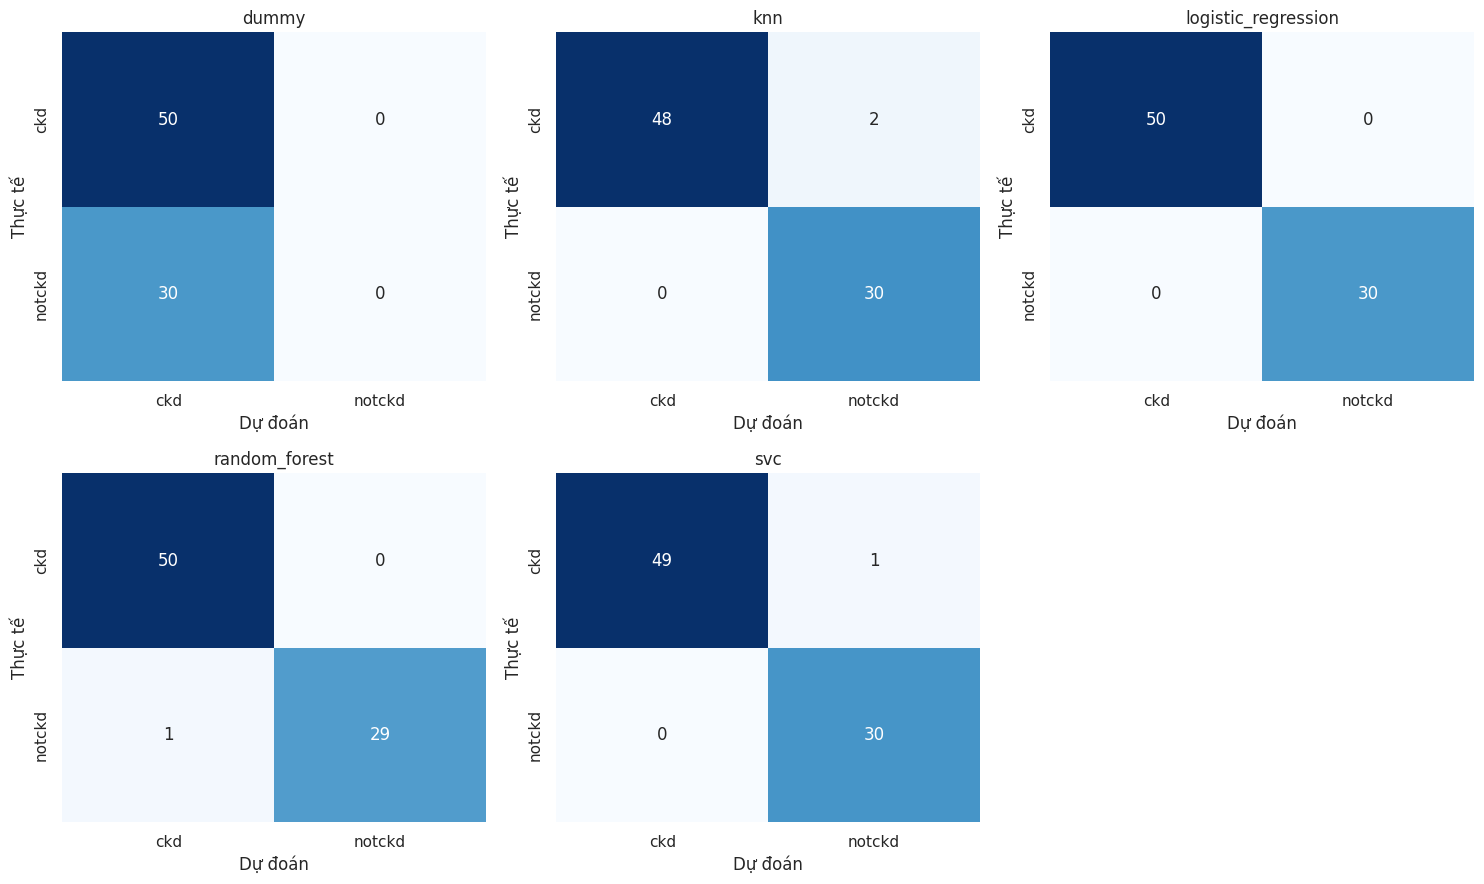

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(15,9))
for axis,name in zip(axes.flat,sorted(confusion_matrices)):
    sns.heatmap(confusion_matrices[name],annot=True,fmt='d',cmap='Blues',cbar=False,
      xticklabels=[POSITIVE_LABEL,NEGATIVE_LABEL],yticklabels=[POSITIVE_LABEL,NEGATIVE_LABEL],ax=axis)
    axis.set(title=name,xlabel='Dự đoán',ylabel='Thực tế')
for axis in axes.flat[len(confusion_matrices):]: axis.set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR/'confusion_matrices.png',dpi=180,bbox_inches='tight'); plt.show()

## 12. Quy tắc chọn model cuối

Loại Dummy; giữ model có F1 cách tốt nhất không quá 0.01; ưu tiên Recall để giảm FN; nếu hòa thì chọn CV std nhỏ, predict nhanh và file nhỏ.

In [ ]:
deployable=evaluation[evaluation.model!='dummy'].copy()
maximum=deployable.f1.max()
eligible=deployable[deployable.f1>=maximum-0.01].copy()
best=eligible.sort_values(
 ['recall','cv_f1_std','predict_ms_per_sample','model_size_bytes'],
 ascending=[False,True,True,True]).iloc[0]
best_name=str(best.model)
print('Ứng viên:',eligible.model.tolist())
print(f'Chọn {best_name}: F1={best.f1:.3f}, Recall={best.recall:.3f}, '
      f'CV std={best.cv_f1_std:.4f}, latency={best.predict_ms_per_sample:.4f} ms/mẫu, '
      f'size={int(best.model_size_bytes):,} bytes.')

Ứng viên: ['logistic_regression', 'random_forest']
Chọn logistic_regression: F1=1.000, Recall=1.000, CV std=0.0000, latency=0.1934 ms/mẫu, size=2,665 bytes.


## 13. Đóng gói model và metadata

model.joblib chứa cả preprocessor + estimator; AI Service không viết lại preprocessing. metadata lưu đúng metric, confusion matrix, version và quy tắc chọn.

In [ ]:
best_pipeline=joblib.load(CANDIDATE_DIR/f'{best_name}.joblib')
assert list(best_pipeline.named_steps['preprocessor'].feature_names_in_)==FEATURES
final_model=MODEL_DIR/'model.joblib'; joblib.dump(best_pipeline,final_model,compress=3)
metadata={'model_name':best_name,'model_version':'1.0.0','task':'binary_classification',
 'target':TARGET,'positive_label':POSITIVE_LABEL,'primary_metric':'f1',
 'selection_rule':'F1 within 0.01, then recall, CV stability, latency and size',
 'metrics':{key:float(best[key]) for key in ['accuracy','precision','recall','f1',
  'roc_auc','pr_auc','cv_f1','cv_f1_std','train_f1','train_test_f1_gap']},
 'confusion_matrix':{'true_positives':int(best.true_positives),
  'false_negatives':int(best.false_negatives),'false_positives':int(best.false_positives),
  'true_negatives':int(best.true_negatives)},
 'trained_at_utc':datetime.now(timezone.utc).isoformat(),'random_state':RANDOM_STATE,
 'features':FEATURES,'library_versions':current_env,'model_size_bytes':final_model.stat().st_size}
(MODEL_DIR/'metadata.json').write_text(
 json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
print(json.dumps(metadata,ensure_ascii=False,indent=2))

{
  "model_name": "logistic_regression",
  "model_version": "1.0.0",
  "task": "binary_classification",
  "target": "classification",
  "positive_label": "ckd",
  "primary_metric": "f1",
  "selection_rule": "F1 within 0.01, then recall, CV stability, latency and size",
  "metrics": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0,
    "pr_auc": 1.0,
    "cv_f1": 1.0,
    "cv_f1_std": 0.0,
    "train_f1": 1.0,
    "train_test_f1_gap": 0.0
  },
  "confusion_matrix": {
    "true_positives": 50,
    "false_negatives": 0,
    "false_positives": 0,
    "true_negatives": 30
  },
  "trained_at_utc": "2026-09-24T14:46:16.530650+00:00",
  "random_state": 42,
  "features": [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wc",
    "rc",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane"
  ],
  "library_versions

## 14. Reload smoke test

Load lại file vừa lưu và dự đoán một DataFrame 24 cột để chứng minh artefact không hỏng.

In [ ]:
reloaded=joblib.load(final_model)
sample=X_test.iloc[[0]][FEATURES]
prediction=reloaded.predict(sample)[0]
probabilities=reloaded.predict_proba(sample)[0]
assert prediction in {POSITIVE_LABEL,NEGATIVE_LABEL}
assert np.isclose(probabilities.sum(),1.0)
print('Dự đoán:',prediction,'| Xác suất:',probabilities)
print('Reload/predict thành công: OK')

Dự đoán: ckd | Xác suất: [9.99886593e-01 1.13407112e-04]
Reload/predict thành công: OK


## 15. Requirements và export cuối

requirements.txt dùng đúng phiên bản runtime tạo model. Đồng bộ chúng với AI Service để load joblib ổn định.

In [ ]:
requirements = '\n'.join([
    f'numpy=={np.__version__}',
    f'pandas=={pd.__version__}',
    f'scikit-learn=={sklearn.__version__}',
    f'joblib=={joblib.__version__}'
]) + '\n'

(MODEL_DIR / 'requirements.txt').write_text(
    requirements,
    encoding='utf-8'
)

if FINAL_EXPORT.exists():
    shutil.rmtree(FINAL_EXPORT)

models_out = FINAL_EXPORT / 'models'
figures_out = FINAL_EXPORT / 'docs' / 'figures'

models_out.mkdir(parents=True)
figures_out.mkdir(parents=True)

artifacts = [
    'model.joblib',
    'schema.json',
    'metadata.json',
    'requirements.txt',
    'training_environment.json',
    'parameter_plan.json',
    'training_results.csv',
    'training_results.json',
    'evaluation_results.csv'
]

for name in artifacts:
    source = MODEL_DIR / name

    if not source.is_file():
        raise FileNotFoundError(source)

    shutil.copy2(source, models_out / name)

for figure in FIGURE_DIR.glob('*.png'):
    shutil.copy2(figure, figures_out / figure.name)

archive = shutil.make_archive(
    str(ROOT / 'ckd_final_artifacts'),
    'zip',
    FINAL_EXPORT
)

print('Đã tạo:', archive)

files.download(archive)

Đã tạo: /content/ckd_colab/ckd_final_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Kết luận

Test dùng đúng một lần; model được so với baseline, train-test gap và FP/FN; lựa chọn cân nhắc deploy; model chứa pipeline đầy đủ; schema, metadata, bảng, hình và requirements đã được export.